# نسخة مع ايموجيز نصية


In [ ]:
# Import the required libraries for data loading and analysis.
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
# Load the dataset.

df = pd.read_csv("/content/SaudiIrony.csv")
TEXT_COLUMN = "Tweets with Decoded emojis"

In [ ]:
# check for missing text, missing labels, and duplicate tweets.

missing_text = df[TEXT_COLUMN].isnull().sum()
missing_labels = df["Final Annotation"].isnull().sum()
duplicates = df.duplicated(subset=[TEXT_COLUMN]).sum()

print("Missing Text:", missing_text)
print("Missing Labels:", missing_labels)
print("Duplicates:", duplicates)


Missing Text: 0
Missing Labels: 0
Duplicates: 182


/tmp/ipython-input-3847802857.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=quality_df, x="Issue", y="Count", palette="magma")


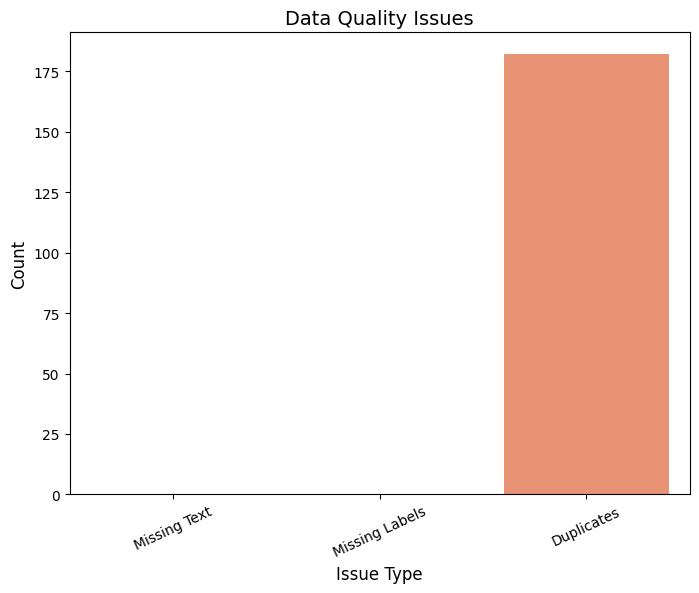

In [ ]:
# Visualize the counts of data quality issues detected in the dataset.

quality_df = pd.DataFrame({
    "Issue": ["Missing Text", "Missing Labels", "Duplicates"],
    "Count": [missing_text, missing_labels, duplicates]
})



plt.figure(figsize=(8, 6))
sns.barplot(data=quality_df, x="Issue", y="Count", palette="magma")

plt.title("Data Quality Issues", fontsize=14)
plt.xlabel("Issue Type", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=25)

plt.show()


/tmp/ipython-input-1271929976.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Final Annotation", palette="viridis")


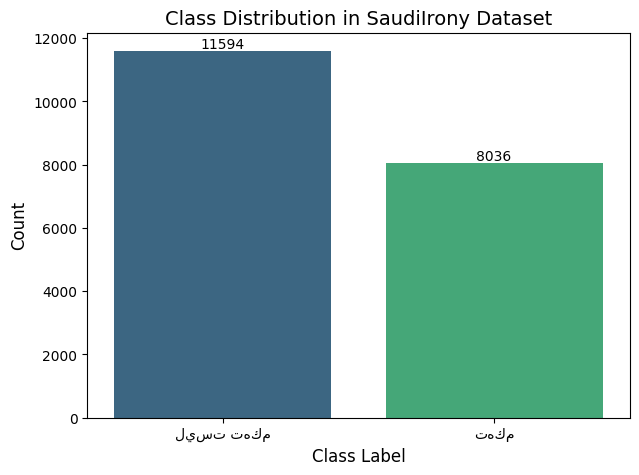

In [ ]:
# Visualize the class distribution of sarcastic vs. non-sarcastic tweets.

plt.figure(figsize=(7,5))
sns.countplot(data=df, x="Final Annotation", palette="viridis")

plt.title("Class Distribution in SaudiIrony Dataset", fontsize=14)
plt.xlabel("Class Label", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Show values on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()


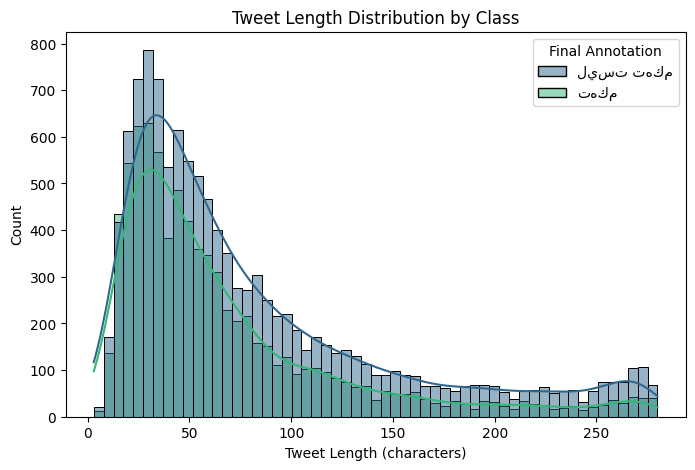

In [ ]:
# Plot the distribution of tweet lengths for each class to inspect writing patterns.

df["tweet_length"] = df[TEXT_COLUMN].astype(str).apply(len)
df["tweet_length"] = df[TEXT_COLUMN].astype(str).apply(len)

plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="tweet_length",
    hue="Final Annotation",
    kde=True,
    palette="viridis"
)
plt.title("Tweet Length Distribution by Class")
plt.xlabel("Tweet Length (characters)")
plt.ylabel("Count")
plt.show()



In [ ]:
# Check for URLs, Mentions, and Hashtags

# Inspect the entire dataset before removing anything

pattern_url = r"http\S+|www\S+"
pattern_mention = r"@\w+"
pattern_hashtag = r"#\w+"

# Create a mask for any tweet containing URLs, mentions, or hashtags
mask_symbols = df[TEXT_COLUMN].str.contains(
    f"{pattern_url}|{pattern_mention}|{pattern_hashtag}",
    regex=True, na=False
)

# Count occurrences
count_symbols = mask_symbols.sum()
total = len(df)

print(f"Total tweets analyzed: {total}")
print(f"Tweets with URLs: {df[TEXT_COLUMN].str.contains(pattern_url, regex=True, na=False).sum()} ({df[TEXT_COLUMN].str.contains(pattern_url, regex=True, na=False).sum()/total:.2%})")
print(f"Tweets with Mentions (@): {df[TEXT_COLUMN].str.contains(pattern_mention, regex=True, na=False).sum()} ({df[TEXT_COLUMN].str.contains(pattern_mention, regex=True, na=False).sum()/total:.2%})")
print(f"Tweets with Hashtags (#): {df[TEXT_COLUMN].str.contains(pattern_hashtag, regex=True, na=False).sum()} ({df[TEXT_COLUMN].str.contains(pattern_hashtag, regex=True, na=False).sum()/total:.2%})")

# Display examples if any symbols are found
if count_symbols > 0:
    print("\nSample tweets containing URLs, mentions, or hashtags:")
    display(df[mask_symbols][[TEXT_COLUMN]].head(10))
else:
    print("\nNo URLs, mentions, or hashtags found in the dataset.")

Total tweets analyzed: 19804
Tweets with URLs: 0 (0.00%)
Tweets with Mentions (@): 0 (0.00%)
Tweets with Hashtags (#): 5 (0.03%)

Sample tweets containing URLs, mentions, or hashtags:


,Tweets with Decoded emojis
1947,#ERROR!
4793,#ERROR!
6897,#ERROR!
7570,#ERROR!
9849,#ERROR!


In [ ]:
#  Remove Tweets with URLs, Mentions, or Hashtags

df_clean = df[~mask_symbols].copy()

print(f"\nOriginal dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_clean)} (removed {count_symbols} rows)")

# Save cleaned version
df_clean.to_csv("SaudiIrony_clean.csv", index=False, encoding="utf-8-sig")
print("File saved as SaudiIrony_clean.csv")


Original dataset size: 19804
Cleaned dataset size: 19799 (removed 5 rows)
File saved as SaudiIrony_clean.csv


In [ ]:
#  Light Text Cleaning for Sarcasm Detection

# Keep emojis and repeated characters, remove only extra spaces.
TEXT_COLUMN = "Tweets with Decoded emojis"

def preprocess_for_sarcasm(text):
    text = str(text)
    text = re.sub(r'\s+', ' ', text).strip()  # normalize spaces
    return text

df_clean["clean_text_processed"] = df_clean[TEXT_COLUMN].apply(preprocess_for_sarcasm)

In [ ]:
# Preview Results

print("\nSample after preprocessing:")
display(df_clean[[TEXT_COLUMN, "clean_text_processed"]].head(10))


Sample after preprocessing:


,Tweets with Decoded emojis,clean_text_processed
0,نعم من علامات الجمال تلك الطيبه التي لاترى بل ...,نعم من علامات الجمال تلك الطيبه التي لاترى بل ...
1,المعرفه الجديده والمهارات الجديده واعتماد طرائ...,المعرفه الجديده والمهارات الجديده واعتماد طرائ...
2,لايشيخ,لايشيخ
3,لايشيخ وكورونا بتزيده مناعه يعني كورونا العن ت...,لايشيخ وكورونا بتزيده مناعه يعني كورونا العن ت...
4,لايشيخ و ليه المفروض اشتري بدل,لايشيخ و ليه المفروض اشتري بدل
5,لايشيخ كيف يكتب وهو نايم,لايشيخ كيف يكتب وهو نايم
6,لايشيخ بالله احلف الاداء و ناثير بالفرثق اثبت ...,لايشيخ بالله احلف الاداء و ناثير بالفرثق اثبت ...
7,طيب دانيه الغلط راكبنها من راسها لين رجولها و ...,طيب دانيه الغلط راكبنها من راسها لين رجولها و ...
8,لا لا توها جاتني تذكره :sob: الله لايحرمني منك...,لا لا توها جاتني تذكره :sob: الله لايحرمني منك...
9,تبا لمن لا يعشقك يشيخ,تبا لمن لا يعشقك يشيخ


In [ ]:
# Class Distribution Check

if "Final Annotation" in df_clean.columns:
    print("\nClass distribution (%):")
    print(df_clean["Final Annotation"].value_counts(normalize=True) * 100)
else:
    print("\nColumn 'Final Annotation' not found (skipping class distribution).")


Class distribution (%):
Final Annotation
ليست تهكم    59.154503
تهكم         40.845497
Name: proportion, dtype: float64


#Baseline Model Implementation


In [ ]:
#  Baseline Models – Import Required Libraries


# Import numerical operations
import numpy as np

# Import data manipulation library
import pandas as pd

# Import train/test splitting function
from sklearn.model_selection import train_test_split

# Import TF-IDF vectorizer for text features
from sklearn.feature_extraction.text import TfidfVectorizer

# Import Logistic Regression baseline model
from sklearn.linear_model import LogisticRegression

# Import Linear Support Vector Classifier
from sklearn.svm import LinearSVC

# Import Naive Bayes baseline models
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB

# Import K-Nearest Neighbors baseline model
from sklearn.neighbors import KNeighborsClassifier

# Import evaluation metrics: accuracy and precision/recall/F1
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)


In [ ]:
# Load the cleaned dataset used for baseline models


# Read the cleaned CSV file into a DataFrame
df_clean = pd.read_csv("/content/SaudiIrony_clean.csv")

# Display the first five rows to verify the data
df_clean.head()


,Tweet ID,Tweets with Decoded emojis,Final Annotation
0,1,نعم من علامات الجمال تلك الطيبه التي لاترى بل ...,ليست تهكم
1,2,المعرفه الجديده والمهارات الجديده واعتماد طرائ...,ليست تهكم
2,3,لايشيخ,تهكم
3,4,لايشيخ وكورونا بتزيده مناعه يعني كورونا العن ت...,تهكم
4,5,لايشيخ و ليه المفروض اشتري بدل,تهكم


In [ ]:
#  Prepare Text and Labels


# Set the text column name that contains cleaned tweets
TEXT_COL  = "Tweets with Decoded emojis"

# Set the label column name that contains sarcasm annotation
LABEL_COL = "Final Annotation"

# Show unique values in the label column (for inspection)
print("Unique label values:")
print(df_clean[LABEL_COL].unique())

# Define a mapping from Arabic labels to numeric classes
label_map = {
    "تهكم": 1,
    "ليست تهكم": 0
}

# Remove rows with missing text or missing label values
df_clean = df_clean.dropna(subset=[TEXT_COL, LABEL_COL]).copy()

# Apply the label mapping to create a numeric label column
df_clean["label"] = df_clean[LABEL_COL].map(label_map)

# Remove rows where mapping failed (label became NaN)
df_clean = df_clean.dropna(subset=["label"]).copy()

# Convert label column to integer type
df_clean["label"] = df_clean["label"].astype(int)

# Print the final label distribution after cleaning
print("\nLabel counts after cleaning:")
print(df_clean["label"].value_counts())

# Extract text values as an array for model input
X_text = df_clean[TEXT_COL].astype(str).values

# Extract numeric labels as an array
y = df_clean["label"].values

# Split dataset into train and test sets (80/20) while keeping class balance
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Print final sizes of training and testing sets
print("\nTrain size:", len(X_train_text))
print("Test size :", len(X_test_text))


Unique label values:
['ليست تهكم' 'تهكم']

Label counts after cleaning:
label
0    11594
1     8036
Name: count, dtype: int64

Train size: 15704
Test size : 3926


In [ ]:
# TF-IDF Feature Extraction (Word-level)


# Create TF-IDF vectorizer using word uni-grams & bi-grams
word_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # Use uni-grams and bi-grams
    max_features=50000,   # Limit vocabulary size
    min_df=5              # Ignore very rare words
)

# Fit TF-IDF on training text and transform it into numeric features
X_train = word_vectorizer.fit_transform(X_train_text)

# Transform testing text using the same TF-IDF model
X_test  = word_vectorizer.transform(X_test_text)

# Show the shape of the resulting TF-IDF matrices
X_train.shape, X_test.shape


((15704, 7999), (3926, 7999))

In [ ]:
#  Train & Evaluate Baseline Models (Word-level TF-IDF)


# Define a helper function to train a model and print basic metrics
def train_and_eval(model, model_name, X_train, y_train, X_test, y_test):
    # Print a visual separator for readability
    print(f"\n{'='*60}")
    # Print the model name being trained
    print(f"Training: {model_name}")
    # Print another separator line
    print('='*60)

    # Fit the model on the training data
    model.fit(X_train, y_train)
    # Predict labels for the test data
    y_pred = model.predict(X_test)

    # Compute accuracy score
    acc = accuracy_score(y_test, y_pred)

    # Compute macro precision, recall, f1 (مطابق للورقة)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="macro"
    )

    # Print accuracy, precision, recall and F1 with 4 decimal places
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall    (macro): {recall:.4f}")
    print(f"F1-score  (macro): {f1:.4f}")

    # Return a dictionary with all metrics for later comparison
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

# Initialize a list to store results for all baseline models
results = []


# Logistic Regression (word-level TF-IDF)

log_reg = LogisticRegression(C=0.01, max_iter=200, solver="liblinear")
results.append(train_and_eval(log_reg, "Logistic Regression",
                              X_train, y_train, X_test, y_test))


# Linear SVM (Support Vector Machine)

svm_clf = LinearSVC(C=2.0)
results.append(train_and_eval(svm_clf, "Linear SVM",
                              X_train, y_train, X_test, y_test))


#  Bernoulli Naive Bayes

bern_nb = BernoulliNB(alpha=1.0)
results.append(train_and_eval(bern_nb, "Bernoulli NB",
                              X_train, y_train, X_test, y_test))


#  Multinomial Naive Bayes

multi_nb = MultinomialNB(alpha=1.0)
results.append(train_and_eval(multi_nb, "Multinomial NB",
                              X_train, y_train, X_test, y_test))


# K-Nearest Neighbors

knn_clf = KNeighborsClassifier(n_neighbors=10)
results.append(train_and_eval(knn_clf, "KNN (k=10)",
                              X_train, y_train, X_test, y_test))


# Gaussian Naive Bayes

gnb = GaussianNB()
results.append(train_and_eval(gnb, "Gaussian NB",
                              X_train.toarray(), y_train,
                              X_test.toarray(), y_test))



Training: Logistic Regression
Accuracy : 0.6286
Precision (macro): 0.6935
Recall    (macro): 0.5525
F1-score  (macro): 0.4909

Training: Linear SVM
Accuracy : 0.6554
Precision (macro): 0.6426
Recall    (macro): 0.6410
F1-score  (macro): 0.6417

Training: Bernoulli NB
Accuracy : 0.6651
Precision (macro): 0.6819
Recall    (macro): 0.6842
F1-score  (macro): 0.6649

Training: Multinomial NB
Accuracy : 0.6882
Precision (macro): 0.6771
Recall    (macro): 0.6757
F1-score  (macro): 0.6764

Training: KNN (k=10)
Accuracy : 0.6610
Precision (macro): 0.6471
Recall    (macro): 0.6397
F1-score  (macro): 0.6414

Training: Gaussian NB
Accuracy : 0.5334
Precision (macro): 0.6132
Recall    (macro): 0.5842
F1-score  (macro): 0.5188


In [ ]:
# Create results table for all baseline models


# Convert the list of model results into a DataFrame
results_df = pd.DataFrame(results)

# Sort models by F1-score (best model at the top)
results_df.sort_values(by="F1", ascending=False, inplace=True)

# Display the sorted baseline model results
results_df


,Model,Accuracy,Precision,Recall,F1
3,Multinomial NB,0.688232,0.677149,0.675719,0.676358
2,Bernoulli NB,0.665053,0.681907,0.684184,0.664938
1,Linear SVM,0.655374,0.642642,0.641027,0.641699
4,KNN (k=10),0.660978,0.647076,0.639657,0.641415
5,Gaussian NB,0.533367,0.613176,0.584177,0.518760
0,Logistic Regression,0.628630,0.693465,0.552474,0.490906


# نسخة مع ايموجيز اصلية`

In [ ]:
# Import Required Libraries

import pandas as pd
import re
import numpy as np


#  Load the Dataset

df = pd.read_csv("/content/SaudiIrony.csv")
TEXT_COLUMN = "Tweets with Decoded emojis"

print("Initial dataset size:", len(df))


# Normalize the text column (convert to string)

df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)


# Smart Removal of Corrupted or Meaningless Rows
#    → Only remove tweets that have NO useful content

def is_bad_row(text):
    """
    Determines whether a row should be removed entirely.
    A row is removed ONLY IF the whole tweet is invalid:
      - pure NaN / None / ERROR
      - tweet is ONLY a URL, ONLY a mention, ONLY a hashtag
      - contains no meaningful Arabic/English characters
    """
    # True NaN values
    if pd.isna(text):
        return True

    t = str(text).strip().lower()

    # Fully invalid entries
    if t in ["nan", "none", "null", "", "#error!", "error", "na"]:
        return True

    # Tweet is ONLY a URL
    if re.fullmatch(r"(http\S+|www\.\S+)", t):
        return True

    # Tweet is ONLY a mention
    if re.fullmatch(r"@\w+", t):
        return True

    # Tweet is ONLY a hashtag
    if re.fullmatch(r"#\w+", t):
        return True

    # If tweet contains real language (Arabic/English), keep it
    if re.search(r"[a-zA-Z\u0600-\u06FF]", t):
        return False

    # Otherwise: no valid content → remove it
    return True


# Apply detection
mask_bad = df[TEXT_COLUMN].apply(is_bad_row)
removed_rows = df[mask_bad]

print("\n Rows that will be REMOVED (invalid entries):")
display(removed_rows[[TEXT_COLUMN]].head(174))
print("Total removed:", mask_bad.sum())

# Remove bad rows
df = df[~mask_bad].copy()



# 5. Replace Textual Emojis → Real Emojis
#    (done BEFORE cleaning to preserve meaning)


def extract_emoji_names(text):
    return re.findall(r':[a-zA-Z0-9_+-]+:', str(text))

# The manual emoji map you provided
manual_map = {
 ":1st_place_medal:": "🥇",
    ":adult:": "🧑",
    ":algeria:": "🇩🇿",
    ":alien:": "👽",
    ":angel:": "😇",
    ":angry:": "😠",
    ":anguished:": "😧",
    ":apple:": "🍎",
    ":arrow_down:": "⬇️",
    ":arrow_heading_down:": "⤵️",
    ":arrow_left:": "⬅️",
    ":arrow_upper_left:": "↖️",
    ":art:": "🎨",
    ":articulated_lorry:": "🚛",
    ":asterisk:": "*️⃣",
    ":astonished:": "😲",
    ":austria:": "🇦🇹",
    ":baby:": "👶",
    ":baby_bottle:": "🍼",
    ":bahrain:": "🇧🇭",
    ":balance_scale:": "⚖️",
    ":balloon:": "🎈",
    ":bangbang:": "‼️",
    ":bar_chart:": "📊",
    ":basketball:": "🏀",
    ":black_flag:": "🏴",
    ":black_heart:": "🖤",
    ":black_nib:": "✒️",
    ":blossom:": "🌼",
    ":blue_heart:": "💙",
    ":blush:": "😊",
    ":books:": "📚",
    ":bouquet:": "💐",
    ":bow:": "🙇",
    ":boy:": "👦",
    ":brain:": "🧠",
    ":bread:": "🍞",
    ":bricks:": "🧱",
    ":briefcase:": "💼",
    ":broken_heart:": "💔",
    ":bulb:": "💡",
    ":burrito:": "🌯",
    ":bust_in_silhouette:": "👤",
    ":butterfly:": "🦋",
    ":call_me_hand:": "🤙",
    ":camera:": "📷",
    ":candy:": "🍬",
    ":canned_food:": "🥫",
    ":cartwheeling:": "🤸",
    ":cd:": "💿",
    ":chart:": "💹",
    ":cherry_blossom:": "🌸",
    ":child:": "🧒",
    ":clap:": "👏",
    ":clapper:": "🎬",
    ":cloud:": "☁️",
    ":clown_face:": "🤡",
    ":coffee:": "☕",
    ":coffin:": "⚰️",
    ":cold_face:": "🥶",
    ":cold_sweat:": "😰",
    ":collision:": "💥",
    ":comet:": "☄️",
    ":confetti_ball:": "🎊",
    ":confounded:": "😖",
    ":confused:": "😕",
    ":cookie:": "🍪",
    ":corn:": "🌽",
    ":cow2:": "🐄",
    ":cowboy_hat_face:": "🤠",
    ":crescent_moon:": "🌙",
    ":crossed_fingers:": "🤞",
    ":crossed_swords:": "⚔️",
    ":crown:": "👑",
    ":cry:": "😢",
    ":crying_cat_face:": "😿",
    ":cupid:": "💘",
    ":cursing_face:": "🤬",
    ":cut_of_meat:": "🥩",
    ":cyclone:": "🌀",
    ":dancer:": "💃",
    ":dancers:": "👯",
    ":dash:": "💨",
    ":diamonds:": "♦️",
    ":disappointed:": "😞",
    ":disappointed_relieved:": "😥",
    ":disguised_face:": "🥸",
    ":dizzy:": "💫",
    ":dizzy_face:": "😵",
    ":dog:": "🐶",
    ":dog2:": "🐕",
    ":dollar:": "💵",
    ":dove:": "🕊️",
    ":drooling_face:": "🤤",
    ":duck:": "🦆",
    ":eagle:": "🦅",
    ":ear_of_rice:": "🌾",
    ":egypt:": "🇪🇬",
    ":envelope_with_arrow:": "📩",
    ":es:": "🇪🇸",
    ":european_union:": "🇪🇺",
    ":evergreen_tree:": "🌲",
    ":exploding_head:": "🤯",
    ":expressionless:": "😑",
    ":eyes:": "👀",
    ":face_with_head_bandage:": "🤕",
    ":face_with_thermometer:": "🤒",
    ":facepalm:": "🤦",
    ":fairy:": "🧚",
    ":fallen_leaf:": "🍂",
    ":fearful:": "😨",
    ":female_sign:": "♀️",
    ":fire:": "🔥",
    ":fish:": "🐟",
    ":fist:": "✊",
    ":fist_right:": "🤜",
    ":flight_departure:": "🛫",
    ":flushed:": "😳",
    ":foot:": "🦶",
    ":footprints:": "👣",
    ":four_leaf_clover:": "🍀",
    ":fr:": "🇫🇷",
    ":frog:": "🐸",
    ":frowning_face:": "☹️",
    ":frowning_person:": "🙍",
    ":fu:": "🖕",
    ":fuelpump:": "⛽",
    ":full_moon_with_face:": "🌝",
    ":gem:": "💎",
    ":ghost:": "👻",
    ":goat:": "🐐",
    ":green_heart:": "💚",
    ":grimacing:": "😬",
    ":grin:": "😁",
    ":grinning:": "😀",
    ":gun:": "🔫",
    ":hand_over_mouth:": "🤭",
    ":handshake:": "🤝",
    ":hatching_chick:": "🐣",
    ":hear_no_evil:": "🙉",
    ":heart:": "❤️",
    ":heart_decoration:": "💟",
    ":heart_eyes:": "😍",
    ":heart_eyes_cat:": "😻",
    ":heartbeat:": "💓",
    ":heartpulse:": "💗",
    ":hearts:": "❤️",
    ":heavy_check_mark:": "✔️",
    ":heavy_dollar_sign:": "💲",
    ":heavy_exclamation_mark:": "❗",
    ":heavy_heart_exclamation:": "❣️",
    ":herb:": "🌿",
    ":hibiscus:": "🌺",
    ":high_heel:": "👠",
    ":hiking_boot:": "🥾",
    ":hot_face:": "🥵",
    ":hourglass_flowing_sand:": "⏳",
    ":house:": "🏠",
    ":house_with_garden:": "🏡",
    ":hugs:": "🤗",
    ":hushed:": "😯",
    ":imp:": "👿",
    ":inbox_tray:": "📥",
    ":information_desk_person:": "💁",
    ":innocent:": "😇",
    ":interrobang:": "⁉️",
    ":iran:": "🇮🇷",
    ":iraq:": "🇮🇶",
    ":it:": "🇮🇹",
    ":japanese_goblin:": "👺",
    ":japanese_ogre:": "👹",
    ":joy:": "😂",
    ":joy_cat:": "😹",
    ":kaaba:": "🕋",
    ":kiss:": "💋",
    ":kissing:": "😗",
    ":kissing_cat:": "😽",
    ":kissing_closed_eyes:": "😚",
    ":kissing_heart:": "😘",
    ":kissing_smiling_eyes:": "😙",
    ":knife:": "🔪",
    ":kuwait:": "🇰🇼",
    ":large_blue_diamond:": "🔷",
    ":leaves:": "🍃",
    ":lebanon:": "🇱🇧",
    ":liberia:": "🇱🇷",
    ":lion:": "🦁",
    ":loop:": "➿",
    ":lotus_position:": "🧘",
    ":loud_sound:": "🔊",
    ":love_letter:": "💌",
    ":love_you_gesture:": "🤟",
    ":lying_face:": "🤥",
    ":m:": "Ⓜ️",
    ":male_sign:": "♂️",
    ":man:": "👨",
    ":man_dancing:": "🕺",
    ":man_shrugging:": "🤷‍♂️",
    ":maple_leaf:": "🍁",
    ":mask:": "😷",
    ":massage:": "💆",
    ":mechanical_arm:": "🦾",
    ":medal_military:": "🎖️",
    ":metal:": "🤘",
    ":money_mouth_face:": "🤑",
    ":money_with_wings:": "💸",
    ":moneybag:": "💰",
    ":monkey:": "🐒",
    ":monocle_face:": "🧐",
    ":morocco:": "🇲🇦",
    ":mortar_board:": "🎓",
    ":mosque:": "🕌",
    ":moyai:": "🗿",
    ":muscle:": "💪",
    ":musical_note:": "🎵",
    ":musical_score:": "🎼",
    ":nail_care:": "💅",
    ":nauseated_face:": "🤢",
    ":negative_squared_cross_mark:": "❎",
    ":nerd_face:": "🤓",
    ":neutral_face:": "😐",
    ":new_moon_with_face:": "🌚",
    ":no_entry:": "⛔",
    ":no_entry_sign:": "🚫",
    ":no_good:": "🙅",
    ":no_mouth:": "😶",
    ":nose:": "👃",
    ":notes:": "🎶",
    ":ok_hand:": "👌",
    ":ok_person:": "🙆",
    ":open_hands:": "👐",
    ":open_mouth:": "😮",
    ":orange_heart:": "🧡",
    ":orthodox_cross:": "✝️",
    ":otter:": "🦦",
    ":owl:": "🦉",
    ":palm_tree:": "🌴",
    ":palms_up_together:": "🙏",
    ":parrot:": "🦜",
    ":partly_sunny:": "⛅",
    ":partying_face:": "🥳",
    ":pensive:": "😔",
    ":persevere:": "😣",
    ":person_with_veil:": "👰",
    ":pinched_fingers:": "🤌",
    ":pinching_hand:": "🤏",
    ":ping_pong:": "🏓",
    ":place_of_worship:": "🛐",
    ":pleading_face:": "🥺",
     ":point_down:": "👇",
    ":point_left:": "👈",
    ":point_right:": "👉",
    ":point_up:": "☝️",
    ":point_up_2:": "👆",
    ":postal_horn:": "📯",
    ":pout:": "😡",
    ":pouting_cat:": "😾",
    ":pray:": "🙏",
    ":princess:": "👸",
    ":punch:": "👊",
    ":purple_heart:": "💜",
    ":qatar:": "🇶🇦",
    ":rabbit:": "🐰",
    ":rainbow:": "🌈",
    ":raised_back_of_hand:": "🤚",
    ":raised_eyebrow:": "🤨",
    ":raised_hand:": "✋",
    ":raised_hands:": "🙌",
    ":raising_hand:": "🙋",
    ":raising_hand_woman:": "🙋‍♀️",
    ":ram:": "🐏",
    ":red_car:": "🚗",
    ":red_circle:": "🔴",
    ":relaxed:": "☺️",
    ":relieved:": "😌",
    ":revolving_hearts:": "💞",
    ":ribbon:": "🎀",
    ":ring:": "💍",
    ":rofl:": "🤣",
    ":roll_eyes:": "🙄",
    ":rose:": "🌹",
    ":running:": "🏃",
    ":running_man:": "🏃‍♂️",
    ":running_woman:": "🏃‍♀️",
    ":sandwich:": "🥪",
    ":satisfied:": "😆",
    ":saudi_arabia:": "🇸🇦",
    ":scream:": "😱",
    ":scream_cat:": "🙀",
    ":see_no_evil:": "🙈",
    ":seedling:": "🌱",
    ":shamrock:": "☘️",
    ":sheep:": "🐑",
    ":shit:": "💩",
    ":shoe:": "👞",
    ":shrug:": "🤷",
    ":shushing_face:": "🤫",
    ":skull:": "💀",
    ":sleeping:": "😴",
    ":sleepy:": "😪",
    ":slightly_frowning_face:": "🙁",
    ":slightly_smiling_face:": "🙂",
    ":smile:": "😄",
    ":smiley:": "😃",
    ":smiling_face_with_tear:": "🥲",
    ":smiling_face_with_three_hearts:": "🥰",
    ":smiling_imp:": "😈",
    ":smirk:": "😏",
    ":smirk_cat:": "😼",
    ":smoking:": "🚬",
    ":snake:": "🐍",
    ":snowman_with_snow:": "☃️",
    ":sob:": "😭",
    ":soccer:": "⚽",
    ":sparkles:": "✨",
    ":sparkling_heart:": "💖",
    ":speak_no_evil:": "🙊",
    ":standing_person:": "🧍",
    ":star2:": "🌟",
    ":star:": "⭐",
    ":star_struck:": "🤩",
    ":stop_sign:": "🛑",
    ":stuck_out_tongue:": "😛",
    ":stuck_out_tongue_closed_eyes:": "😝",
    ":stuck_out_tongue_winking_eye:": "😜",
    ":sun_with_face:": "🌞",
    ":sunflower:": "🌻",
    ":sunglasses:": "😎",
    ":sweat:": "😓",
    ":sweat_drops:": "💦",
    ":sweat_smile:": "😅",
    ":syringe:": "💉",
    ":tada:": "🎉",
    ":telephone_receiver:": "📞",
    ":thinking:": "🤔",
    ":thought_balloon:": "💭",
    ":thumbsdown:": "👎",
    ":thumbsup:": "👍",
    ":tiger2:": "🐅",
    ":tiger:": "🐯",
    ":timer_clock:": "⏲️",
    ":tired_face:": "😫",
    ":tongue:": "👅",
    ":tooth:": "🦷",
    ":triumph:": "😤",
    ":trophy:": "🏆",
    ":tulip:": "🌷",
    ":turtle:": "🐢",
    ":two_hearts:": "💕",
    ":uk:": "🇬🇧",
    ":umbrella:": "☂️",
    ":unamused:": "😒",
    ":unicorn:": "🦄",
    ":united_arab_emirates:": "🇦🇪",
    ":upside_down_face:": "🙃",
    ":us:": "🇺🇸",
    ":v:": "✌️",
    ":violin:": "🎻",
    ":vomiting_face:": "🤮",
    ":walking:": "🚶",
    ":walking_man:": "🚶‍♂️",
    ":warning:": "⚠️",
    ":wave:": "👋",
    ":weary:": "😩",
    ":white_check_mark:": "✅",
    ":white_heart:": "🤍",
    ":wilted_flower:": "🥀",
    ":wink:": "😉",
    ":woman:": "👩",
    ":woman_facepalming:": "🤦‍♀️",
    ":woozy_face:": "🥴",
    ":worried:": "😟",
    ":writing_hand:": "✍️",
    ":x:": "❌",
    ":yellow_heart:": "💛",
    ":yum:": "😋",
    ":zany_face:": "🤪",
    ":zap:": "⚡",
    ":zebra:": "🦓",
    ":zzz:": "💤"
}
def replace_textual_emojis(text):
    text = str(text)
    for k, v in manual_map.items():
        text = text.replace(k, v)
    return text

df[TEXT_COLUMN] = df[TEXT_COLUMN].apply(replace_textual_emojis)



# Clean tweets WITHOUT deleting useful content
def clean_tweet(text):
    text = str(text)

    # Remove repeated character elongation (e.g., "حلوووو" → "حلوو")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Remove Arabic diacritics
    text = re.sub(r"[\u0617-\u061A\u064B-\u0652]", "", text)

    # Remove URLs inside sentences
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove mentions inside sentences
    text = re.sub(r"@\w+", " ", text)

    # Keep hashtag words but remove the #
    text = text.replace("#", "")

    # Remove unwanted characters but keep Arabic, English, and emojis
    text = re.sub(
        r"[^\w\s\u0600-\u06FF"
        r"\U0001F600-\U0001F64F"
        r"\U0001F300-\U0001F5FF"
        r"\U0001F680-\U0001F6FF"
        r"\U0001F1E6-\U0001F1FF]",
        " ",
        text
    )

    # Remove digits
    text = re.sub(r"\d+", " ", text)

    # Normalize excessive spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


df["clean_text"] = df[TEXT_COLUMN].apply(clean_tweet)



# Show cleaning results

print("\nDataset size AFTER cleaning:", len(df))

print("\n Sample of cleaned tweets:")
display(df[["clean_text"]].head())



# Save the final cleaned dataset
output_path = "/content/SaudiIrony_clean.csv"
df.to_csv(output_path, index=False)

print("\n Cleaning completed! Final dataset saved as:", output_path)

Initial dataset size: 19804

 Rows that will be REMOVED (invalid entries):


,Tweets with Decoded emojis
975,nan
1163,nan
1240,nan
1244,nan
1646,nan
...,...
19227,nan
19720,nan
19721,nan
19722,nan


Total removed: 174

Dataset size AFTER cleaning: 19630

 Sample of cleaned tweets:


,clean_text
0,نعم من علامات الجمال تلك الطيبه التي لاترى بل ...
1,المعرفه الجديده والمهارات الجديده واعتماد طرائ...
2,لايشيخ
3,لايشيخ وكورونا بتزيده مناعه يعني كورونا العن ت...
4,لايشيخ و ليه المفروض اشتري بدل



 Cleaning completed! Final dataset saved as: /content/SaudiIrony_clean.csv


In [ ]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.6 MB/s eta 0:00:00


In [ ]:
!pip install arabert
!pip install evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 9.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.8 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=120cae7ee9e7c0cf263010707a5bba2ba0ec6ca3fa4c9e3428ad2d59bdeecae9
  Stored in directory: /root/.cache/pip/wheels/bb/f1/26/f9002669ef6ad80a3c9f1b22880b35d9b4c6650011acee0523
Successfully built emoji


In [ ]:
# INSTALL & IMPORTS & CLEANUP

import gc
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModel, AutoConfig,
    Trainer, TrainingArguments, DataCollatorWithPadding
)
from transformers.modeling_outputs import SequenceClassifierOutput
from arabert.preprocess import ArabertPreprocessor
import torch.nn as nn
import evaluate


gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


# MODEL ARCHITECTURE (4-Layers)
class ConcatBertModel(nn.Module):
    def __init__(self, model_name, num_labels=2, class_weights=None):
        super(ConcatBertModel, self).__init__()
        self.num_labels = num_labels
        self.class_weights = class_weights

        self.config = AutoConfig.from_pretrained(model_name)
        self.config.output_hidden_states = True
        self.bert = AutoModel.from_pretrained(model_name, config=self.config)


        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(768 * 4, num_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, labels=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        hidden_states = outputs.hidden_states

        pooled_output = torch.cat(tuple([hidden_states[i][:, 0, :] for i in [-1, -2, -3, -4]]), dim=-1)
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
            loss = loss_fct(logits.view(-1, self.num_labels), labels.view(-1))

        return SequenceClassifierOutput(loss=loss, logits=logits)


# PREPARE DATA (PURE ORIGINAL DATA ONLY )
model_name = "aubmindlab/bert-base-arabertv02-twitter"
arabert_prep = ArabertPreprocessor(model_name=model_name)
tokenizer = AutoTokenizer.from_pretrained(model_name)

print("Loading ORIGINAL Data Only...")
df_original = pd.read_csv("SaudiIrony_clean.csv")
df_original['clean_text'] = df_original["Tweets with Decoded emojis"].apply(lambda x: arabert_prep.preprocess(str(x)))
label_map = {"ليست تهكم": 0, "تهكم": 1}
df_original["label"] = df_original["Final Annotation"].map(label_map).dropna().astype(int)

# Keep only required columns
df_original = df_original[["clean_text", "label"]]

# Split 20% as final test set
from sklearn.model_selection import train_test_split
df_train_full, df_test_holdout = train_test_split(
    df_original, test_size=0.20, random_state=42, stratify=df_original["label"]
)

print(f"Train Size: {len(df_train_full)}")
print(f"Test Size:  {len(df_test_holdout)}")

# Prepare test dataset for later prediction
test_ds = Dataset.from_pandas(df_test_holdout.reset_index(drop=True))
def tokenize(batch):
    return tokenizer(batch["clean_text"], truncation=True, padding=False, max_length=128)
test_tok = test_ds.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

test_probs_sum = np.zeros((len(df_test_holdout), 2))


# START K-FOLD (FAST RUN)
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

print(f"\n Starting {N_FOLDS}-Fold Cross Validation on PURE DATA...")

X_train = df_train_full.index.values
y_train = df_train_full["label"].values

acc_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(pred):
    logits = pred.predictions
    preds = logits.argmax(-1)
    labels = pred.label_ids
    return {
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    }

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
    print(f"\n Running Fold {fold+1}/{N_FOLDS}...")

    fold_train_df = df_train_full.iloc[train_idx]
    fold_val_df = df_train_full.iloc[val_idx]

    train_ds = Dataset.from_pandas(fold_train_df.reset_index(drop=True))
    val_ds = Dataset.from_pandas(fold_val_df.reset_index(drop=True))

    train_tok = train_ds.map(tokenize, batched=True)
    val_tok = val_ds.map(tokenize, batched=True)

    labels = fold_train_df["label"].values
    class_weights = compute_class_weight("balanced", classes=np.unique(labels), y=labels)
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

    model = ConcatBertModel(model_name=model_name, num_labels=2, class_weights=weights_tensor).to(device)

    training_args = TrainingArguments(
        output_dir=f"arabert_pure_fold_{fold+1}",
        num_train_epochs=5,           # 5 epochs suitable for a small dataset
        learning_rate=2e-5,
        per_device_train_batch_size=16, # Larger batch since dataset is small
        gradient_accumulation_steps=1,
        fp16=True,
        weight_decay=0.01,             # Light regularization for clean data
        warmup_ratio=0.1,
        save_strategy="epoch",
        eval_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        save_total_limit=1,
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )

    trainer.train()

    preds_output = trainer.predict(test_tok)
    probs = torch.softmax(torch.tensor(preds_output.predictions), dim=-1).numpy()
    test_probs_sum += probs

    del model, trainer, probs
    gc.collect()
    torch.cuda.empty_cache()


# FINAL RESULTS
print("\n" + "="*50)
print(" FINAL RESULTS (Pure Data + 5-Fold Ensemble)")
print("="*50)

avg_probs = test_probs_sum / N_FOLDS
true_labels = df_test_holdout["label"].values

best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.95, 0.01):
    p = (avg_probs[:, 1] >= thresh).astype(int)
    score = f1_score(true_labels, p, average="macro")
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

final_preds = (avg_probs[:, 1] >= best_thresh).astype(int)
final_acc = accuracy_score(true_labels, final_preds)

print(f"Best Threshold: {best_thresh:.2f}")
print(f"Accuracy: {final_acc:.4f}")
print(f"F1-Score (Macro): {best_f1:.4f}")
print("-" * 50)
print(classification_report(true_labels, final_preds, target_names=["Not Sarcastic", "Sarcastic"]))

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/476 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/12564 [00:00<?, ? examples/s]

Map:   0%|          | 0/3140 [00:00<?, ? examples/s]

Some weights of BertModel were not initialized from the model checkpoint at aubmindlab/bert-base-arabertv02-twitter and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-2690243160.py:151: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,F1 Macro
1,0.634200,0.582356,0.692705
2,0.555400,0.598137,0.688062
3,0.479600,0.672080,0.679280
4,0.339600,0.800255,0.668471
5,0.269300,0.916633,0.669488



 FINAL RESULTS (Pure Data + 5-Fold Ensemble)
Best Threshold: 0.59
Accuracy: 0.7252
F1-Score (Macro): 0.7116
--------------------------------------------------
               precision    recall  f1-score   support

Not Sarcastic       0.75      0.80      0.77      2319
    Sarcastic       0.68      0.62      0.65      1607

     accuracy                           0.73      3926
    macro avg       0.72      0.71      0.71      3926
 weighted avg       0.72      0.73      0.72      3926



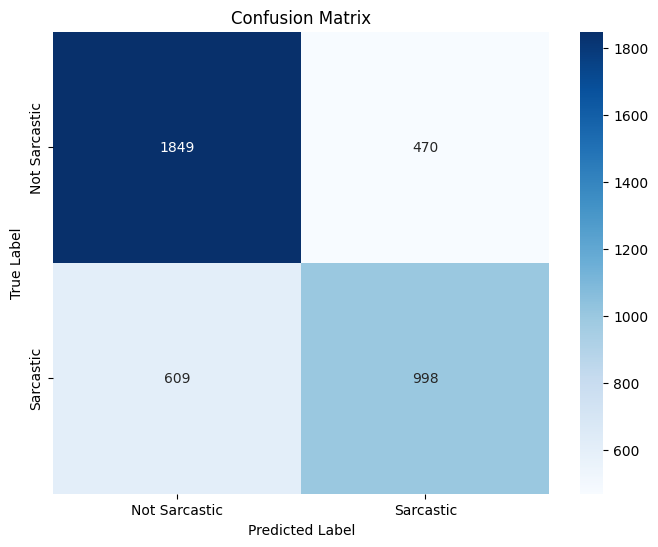

In [ ]:
# Generate and visualize the confusion matrix for the final model predictions.

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, final_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Not Sarcastic", "Sarcastic"],
            yticklabels=["Not Sarcastic", "Sarcastic"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Compute and report the ROC–AUC score using the model’s predicted probabilities.

from sklearn.metrics import roc_curve, roc_auc_score

auc_score = roc_auc_score(true_labels, avg_probs[:, 1])

fpr, tpr, thresholds = roc_curve(true_labels, avg_probs[:, 1])

print(f" AUC Score: {auc_score:.4f}")



 AUC Score: 0.7765


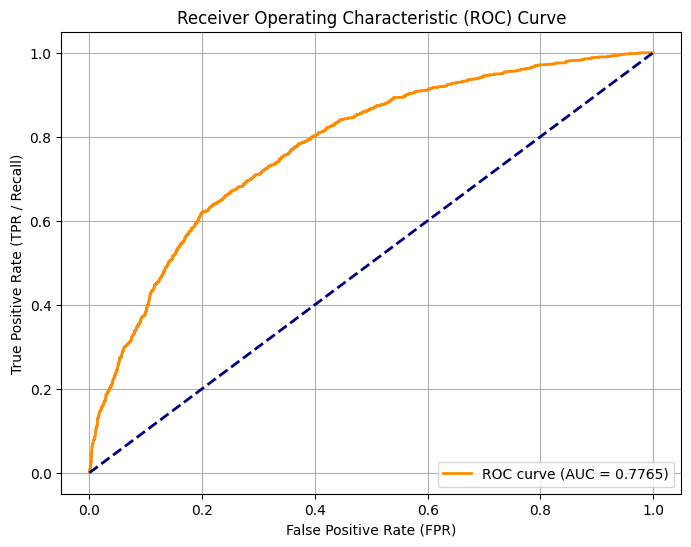

In [ ]:
# Plot the ROC curve.

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()